In [4]:
from pathlib import Path
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from zipfile import ZipFile


In [5]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def download_if_needed(url, path):
    if not path.exists():
        print(f"Downloading {path.name}...")
        r = requests.get(url)
        r.raise_for_status()
        path.write_bytes(r.content)
    else:
        print(f"{path.name} already exists.")

def extract_if_needed(zip_path, extract_folder):
    if not extract_folder.exists():
        print(f"Extracting {zip_path.name}...")
        with ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_folder)
    else:
        print(f"{extract_folder.name} already exists.")


loc_url = 'https://data.london.gov.uk/download/24rz6/77d9b319-931e-4090-bf8e-f578938bd352/LSOA2011%20AvPTAI2015.csv'
loc_path =  DATA_DIR / "location.csv"
crime_url = 'https://data.london.gov.uk/download/exy3m/vm7/MPS%20LSOA%20Level%20Crime%20(Historical).csv'
crime_path = DATA_DIR / "crime.csv"
deprivation_url = "https://assets.publishing.service.gov.uk/media/5dc407b440f0b6379a7acc8d/File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv"
deprivation_path = DATA_DIR / "deprivation.csv" 
house_url = "https://www.ons.gov.uk/file?uri=/peoplepopulationandcommunity/housing/datasets/medianpricepaidbylowerlayersuperoutputareahpssadataset46/current/hpssadataset46medianpricepaidforresidentialpropertiesbylsoa.zip"
house_zip = DATA_DIR / "house_prices.zip"
house_path = DATA_DIR / "house_prices"
download_if_needed(loc_url,loc_path)
download_if_needed(crime_url,crime_path)
download_if_needed(deprivation_url,deprivation_path)
download_if_needed(house_url, house_zip)
extract_if_needed(house_zip, house_path)

location.csv already exists.
crime.csv already exists.
deprivation.csv already exists.
house_prices.zip already exists.
house_prices already exists.


In [6]:
excel_file = next(house_path.glob("*.xls"))
loc_df = pd.read_csv('data/location.csv')
crime_df = pd.read_csv('data/crime.csv')
IoD_df = pd.read_csv('data/deprivation.csv')
house_df = pd.read_excel(
    excel_file,
    sheet_name="1a",
    header=5
)

In [7]:
print(loc_df.columns)
print(crime_df.columns)
print(IoD_df.columns)
print(house_df.columns)

Index(['LSOA2011', 'AvPTAI2015', 'PTAL', 'PTAIHigh', 'PTAILow'], dtype='str')
Index(['LSOA Code', 'LSOA Name', 'Borough', 'Group', 'SubGroup', '202007',
       '202008', '202009', '202010', '202011', '202012', '202101', '202102',
       '202103', '202104', '202105', '202106', '202107', '202108', '202109',
       '202110', '202111', '202112', '202201', '202202', '202203', '202204',
       '202205', '202206', '202207', '202208', '202209', '202210', '202211',
       '202212', '202301', '202302', '202303', '202304', '202305', '202306',
       '202307', '202308', '202309', '202310', '202311', '202312', '202401',
       '202402', '202403', '202404', '202405', '202406'],
      dtype='str')
Index(['LSOA code (2011)', 'LSOA name (2011)',
       'Local Authority District code (2019)',
       'Local Authority District name (2019)',
       'Index of Multiple Deprivation (IMD) Score',
       'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)',
       'Index of Multiple Deprivation

In [8]:
 
loc_df = loc_df[['LSOA2011', 'AvPTAI2015', 'PTAL']]
crime_df = crime_df[['LSOA Code', 'Group','202201', '202202', '202203', '202204', '202205', '202206',
       '202207', '202208', '202209', '202210', '202211', '202212']]
IoD_df = IoD_df[['LSOA code (2011)', 'LSOA name (2011)',
       'Local Authority District code (2019)',
       'Local Authority District name (2019)',
       'Index of Multiple Deprivation (IMD) Score']]
house_df = house_df[['Local authority code', 'Local authority name', 'LSOA code',
       'LSOA name', 'Year ending Dec 2021', 'Year ending Mar 2022',
       'Year ending Jun 2022', 'Year ending Sep 2022', 'Year ending Dec 2022']]


In [9]:
# print(loc_df.head())
# print(crime_df.head())
# print(IoD_df.head())
# print(house_df.head())

In [10]:
house_london = house_df[house_df["Local authority code"].astype(str).str.startswith("E09", na=False)].copy()
price_cols = [
    "Year ending Dec 2022",
    "Year ending Sep 2022",
    "Year ending Jun 2022",
    "Year ending Mar 2022",
    "Year ending Dec 2021"
]
house_london[price_cols] = house_london[price_cols].replace(":", pd.NA)

house_london[price_cols] = house_london[price_cols].apply(pd.to_numeric)

# Create the final house price column by taking the first available value
house_london["house_price_2022"] = house_london[price_cols].bfill(axis=1).iloc[:, 0]

# Convert each row to True/False for missing values. idxmax(axis=1) returns the name of the first column containing True.
house_london["price_source"] = house_london[price_cols].notna().idxmax(axis=1)

# idxmax returns the first column even when all values are missing, so we need to label those rows correctly
house_london.loc[house_london["house_price_2022"].isna(),"price_source"] = "Missing"

print(house_london["price_source"].value_counts())
house_london=house_london.drop(columns = price_cols)


price_source
Year ending Dec 2022    4496
Missing                  111
Year ending Mar 2022      86
Year ending Sep 2022      64
Year ending Jun 2022      43
Year ending Dec 2021      35
Name: count, dtype: int64


In [11]:
crime_months = [
    "202201", "202202", "202203", "202204",
    "202205", "202206", "202207", "202208",
    "202209", "202210", "202211", "202212"
]

crime_df[crime_months] = crime_df[crime_months].apply(pd.to_numeric,errors="coerce").fillna(0)

crime_df["crime_total_2022"] = crime_df[crime_months].sum(axis=1)
total_crime_df = crime_df.drop(columns = crime_months).copy()


In [ ]:
crime_by_lsoa = (
    total_crime_df
    .pivot_table(
        index="LSOA Code",
        columns="Group",
        values="crime_total_2022",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)


# Remove the name added above the pivoted columns
crime_by_lsoa.columns.name = None

# Add total crime across all crime-category columns
crime_by_lsoa["total_crime_2022"] = (crime_by_lsoa.drop(columns="LSOA Code").sum(axis=1))



(4991, 12)

In [13]:
look_up_url = 'https://open-geography-portalx-ons.hub.arcgis.com/api/download/v1/items/b684a0dbf786473f9563ec0616da2f8b/csv?layers=0'
look_up_path = DATA_DIR / "lookup.csv" 
download_if_needed(look_up_url,look_up_path)
lookup_df = pd.read_csv('data/lookup.csv')
lookup_df = lookup_df[['LSOA11CD','LSOA21CD']]


lookup.csv already exists.


In [14]:
crime_2011 = crime_by_lsoa.merge(
    lookup_df,
    left_on="LSOA Code",
    right_on="LSOA21CD",
    how="inner"
)

In [15]:
house_crime = house_london.merge(
    crime_2011,
    left_on="LSOA code",
    right_on="LSOA11CD",
    how="left",
    validate="one_to_one"
)

house_crime = house_crime.drop(columns=["LSOA11CD","LSOA21CD","LSOA Code"])

In [16]:
print(f"House price LSOAs: {len(house_london)}")
print(f"Crime LSOAs after lookup: {len(crime_2011)}")
print(f"Merged dataset: {len(house_crime)}")
print(f"Unmatched house-price LSOAs: {house_crime['total_crime_2022'].isna().sum()}")


missing = house_crime[house_crime["total_crime_2022"].isna()]

missing["Local authority name"].value_counts()

House price LSOAs: 4835
Crime LSOAs after lookup: 4832
Merged dataset: 4835
Unmatched house-price LSOAs: 3


Local authority name
City of London    3
Name: count, dtype: int64

In [17]:
deprivation_transport = IoD_df.merge(
    loc_df,
    left_on="LSOA code (2011)",
    right_on="LSOA2011",
    how="left",
    validate="one_to_one"
)

# Drop the duplicate transport LSOA code
deprivation_transport = deprivation_transport.drop(columns=['Local Authority District code (2019)','Local Authority District name (2019)','LSOA name (2011)','LSOA2011'])
deprivation_transport = deprivation_transport.rename(
    columns={
        'Index of Multiple Deprivation (IMD) Score': 'IMD score',
        "LSOA code (2011)": "LSOA code"
    }
)



In [18]:
final_df = house_crime.merge(
    deprivation_transport,
    on="LSOA code",
    how="left",
    validate="one_to_one"
)

In [19]:
output_path = DATA_DIR / "final_dataset.csv"
final_df.to_csv(output_path, index=False)

print(final_df.shape)
print(final_df.columns)

final_df.head()

(4835, 20)
Index(['Local authority code', 'Local authority name', 'LSOA code',
       'LSOA name', 'house_price_2022', 'price_source',
       'ARSON AND CRIMINAL DAMAGE', 'BURGLARY', 'DRUG OFFENCES',
       'MISCELLANEOUS CRIMES AGAINST SOCIETY', 'POSSESSION OF WEAPONS',
       'PUBLIC ORDER OFFENCES', 'ROBBERY', 'THEFT', 'VEHICLE OFFENCES',
       'VIOLENCE AGAINST THE PERSON', 'total_crime_2022', 'IMD score',
       'AvPTAI2015', 'PTAL'],
      dtype='str')


,Local authority code,Local authority name,LSOA code,LSOA name,house_price_2022,price_source,ARSON AND CRIMINAL DAMAGE,BURGLARY,DRUG OFFENCES,MISCELLANEOUS CRIMES AGAINST SOCIETY,POSSESSION OF WEAPONS,PUBLIC ORDER OFFENCES,ROBBERY,THEFT,VEHICLE OFFENCES,VIOLENCE AGAINST THE PERSON,total_crime_2022,IMD score,AvPTAI2015,PTAL
0,E09000001,City of London,E01000001,City of London 001A,880000.0,Year ending Dec 2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.208,69.8233,6b
1,E09000001,City of London,E01000002,City of London 001B,850000.0,Year ending Dec 2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.143,83.7820,6b
2,E09000001,City of London,E01000003,City of London 001C,540000.0,Year ending Dec 2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.402,41.7417,6b
3,E09000001,City of London,E01000005,City of London 001E,NaN,Missing,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,28.652,85.8893,6b
4,E09000001,City of London,E01032739,City of London 001F,756250.0,Year ending Dec 2022,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,13.584,111.4790,6b


In [23]:
print(final_df.shape)
print(final_df.dtypes)

(4835, 20)
Local authority code                        str
Local authority name                        str
LSOA code                                   str
LSOA name                                   str
house_price_2022                        float64
price_source                                str
ARSON AND CRIMINAL DAMAGE               float64
BURGLARY                                float64
DRUG OFFENCES                           float64
MISCELLANEOUS CRIMES AGAINST SOCIETY    float64
POSSESSION OF WEAPONS                   float64
PUBLIC ORDER OFFENCES                   float64
ROBBERY                                 float64
THEFT                                   float64
VEHICLE OFFENCES                        float64
VIOLENCE AGAINST THE PERSON             float64
total_crime_2022                        float64
IMD score                               float64
AvPTAI2015                              float64
PTAL                                        str
dtype: object


In [20]:
print("Missing house prices:", final_df["house_price_2022"].isna().sum())

print("Missing crime:", final_df["total_crime_2022"].isna().sum())

print("Missing IMD:", final_df["IMD score"].isna().sum())

print("Missing PTAI:", final_df["AvPTAI2015"].isna().sum())

Missing house prices: 111
Missing crime: 3
Missing IMD: 0
Missing PTAI: 0


In [24]:
missing = pd.DataFrame({
    "Missing values": final_df.isna().sum(),
    "Percentage": (final_df.isna().mean() * 100).round(2)
})

print(missing[missing["Missing values"] > 0])

                                      Missing values  Percentage
house_price_2022                                 111        2.30
ARSON AND CRIMINAL DAMAGE                          3        0.06
BURGLARY                                           3        0.06
DRUG OFFENCES                                      3        0.06
MISCELLANEOUS CRIMES AGAINST SOCIETY               3        0.06
POSSESSION OF WEAPONS                              3        0.06
PUBLIC ORDER OFFENCES                              3        0.06
ROBBERY                                            3        0.06
THEFT                                              3        0.06
VEHICLE OFFENCES                                   3        0.06
VIOLENCE AGAINST THE PERSON                        3        0.06
total_crime_2022                                   3        0.06


In [25]:
print(f"Duplicate rows: {final_df.duplicated().sum()}")
print(f"Duplicate LSOA codes: {final_df['LSOA code'].duplicated().sum()}")

Duplicate rows: 0
Duplicate LSOA codes: 0


In [ ]:
numeric_cols = [
    "house_price_2022",
    "total_crime_2022",
    "IMD score",
    "AvPTAI2015"
]

summary = final_df[numeric_cols].describe().T
summary["median"] = final_df[numeric_cols].median()
summary["skewness"] = final_df[numeric_cols].skew()

summary = summary[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max", "skewness"]]

summary.round(2)

,count,mean,median,std,min,25%,50%,75%,max,skewness
house_price_2022,4724.0,618617.49,520000.00,398390.23,147500.00,420000.00,520000.00,685000.0,6425000.00,5.22
total_crime_2022,4832.0,165.14,114.00,375.27,1.00,79.00,114.00,171.0,13568.00,25.30
IMD score,4835.0,21.50,20.38,10.90,2.33,12.45,20.38,29.6,64.68,0.40
AvPTAI2015,4835.0,13.34,9.51,12.54,0.19,5.49,9.51,17.0,121.89,2.92


C:\Users\Olesya Drozhzhina\AppData\Local\Temp\ipykernel_19216\3992716338.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(final_df[col].dropna(), vert=False)


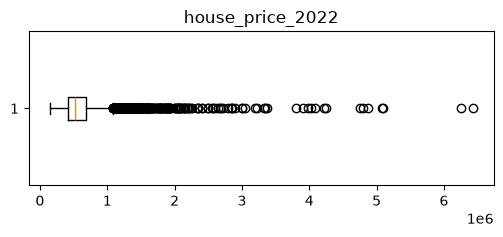

C:\Users\Olesya Drozhzhina\AppData\Local\Temp\ipykernel_19216\3992716338.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(final_df[col].dropna(), vert=False)


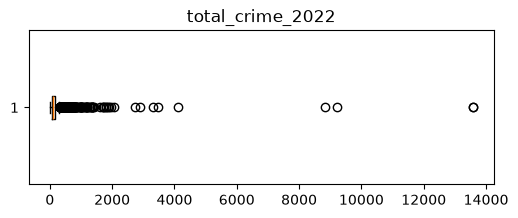

C:\Users\Olesya Drozhzhina\AppData\Local\Temp\ipykernel_19216\3992716338.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(final_df[col].dropna(), vert=False)


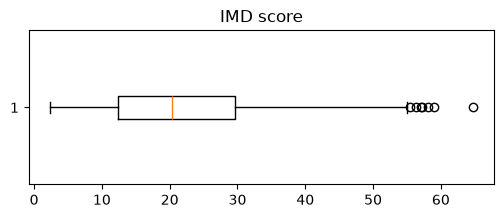

C:\Users\Olesya Drozhzhina\AppData\Local\Temp\ipykernel_19216\3992716338.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(final_df[col].dropna(), vert=False)


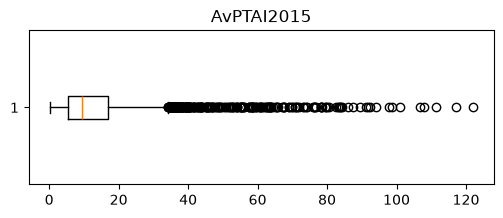

In [27]:
for col in numeric_cols:
    plt.figure(figsize=(6,2))
    plt.boxplot(final_df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

In [ ]:
final_df.nlargest(10,"house_price_2022")[["LSOA name", "Local authority name", "house_price_2022"]]

,LSOA name,Local authority name,house_price_2022
2919,Kensington and Chelsea 010C,Kensington and Chelsea,6425000.0
206,Barnet 033B,Barnet,6250000.0
4744,Westminster 019C,Westminster,5100000.0
2894,Kensington and Chelsea 011E,Kensington and Chelsea,5075000.0
4814,Westminster 011E,Westminster,4875000.0
4742,Westminster 019A,Westminster,4795000.0
2932,Kensington and Chelsea 018E,Kensington and Chelsea,4750000.0
3499,Merton 002D,Merton,4250000.0
4631,Wandsworth 013D,Wandsworth,4225000.0
4726,Westminster 023C,Westminster,4083500.0


In [ ]:
final_df.nlargest(10,"total_crime_2022")[["LSOA name", "Local authority name", "total_crime_2022"]]

,LSOA name,Local authority name,total_crime_2022
4821,Westminster 013E,Westminster,13568.0
4822,Westminster 013F,Westminster,13568.0
4788,Westminster 018A,Westminster,9206.0
4815,Westminster 013B,Westminster,8822.0
4790,Westminster 018C,Westminster,4119.0
2467,Hillingdon 031A,Hillingdon,3484.0
4789,Westminster 018B,Westminster,3301.0
4768,Westminster 011B,Westminster,2883.0
2996,Kingston upon Thames 009C,Kingston upon Thames,2735.0
1864,Hackney 027G,Hackney,2044.0


In [30]:

corr = final_df[numeric_cols].corr()

corr.round(2)

,house_price_2022,total_crime_2022,IMD score,AvPTAI2015
house_price_2022,1.00,0.06,-0.34,0.18
total_crime_2022,0.06,1.00,0.11,0.35
IMD score,-0.34,0.11,1.00,0.15
AvPTAI2015,0.18,0.35,0.15,1.00


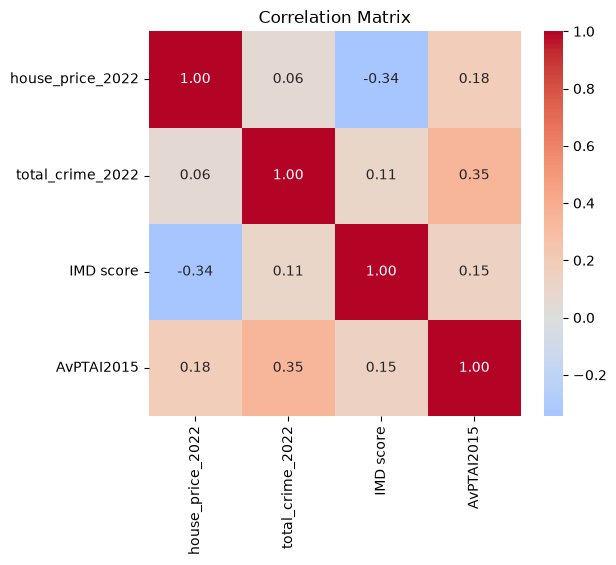

In [31]:
plt.figure(figsize=(6,5))

sns.heatmap(corr,annot=True,cmap="coolwarm",center=0,fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

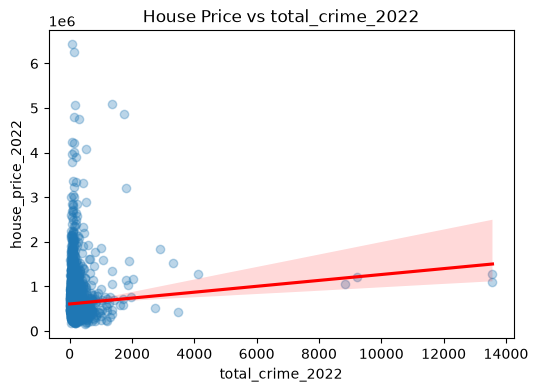

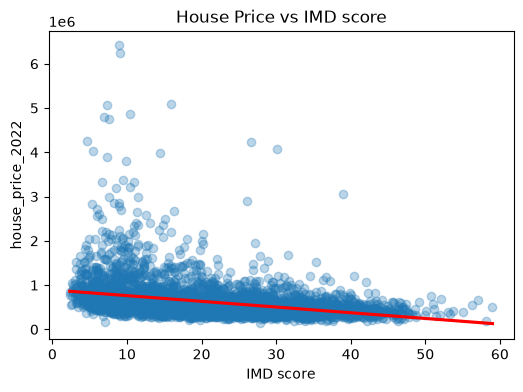

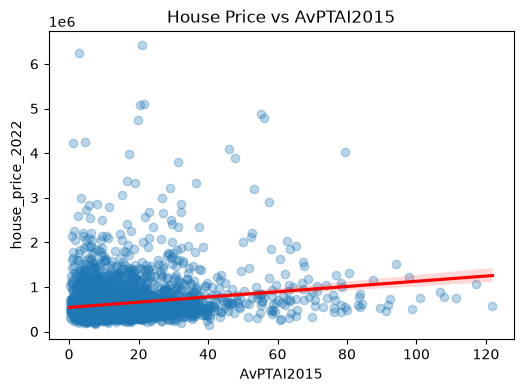

In [ ]:
variables = ["total_crime_2022","IMD score","AvPTAI2015"]

for var in variables:
    plt.figure(figsize=(6,4))

    sns.regplot(
        data=final_df,
        x=var,
        y="house_price_2022",
        scatter_kws={"alpha":0.3},
        line_kws={"color":"red"}
    )

    plt.title(f"House Price vs {var}")
    plt.show()